Dataset Shape: (3999, 12)

Missing Values:
ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

Numeric Columns Used:
['Balance', 'Qual_miles', 'cc1_miles', 'cc2_miles', 'cc3_miles', 'Bonus_miles', 'Bonus_trans', 'Flight_miles_12mo', 'Flight_trans_12', 'Days_since_enroll', 'Award?']

Shape Before Outlier Removal : (3999, 11)
Shape After Outlier Removal  : (1785, 11)


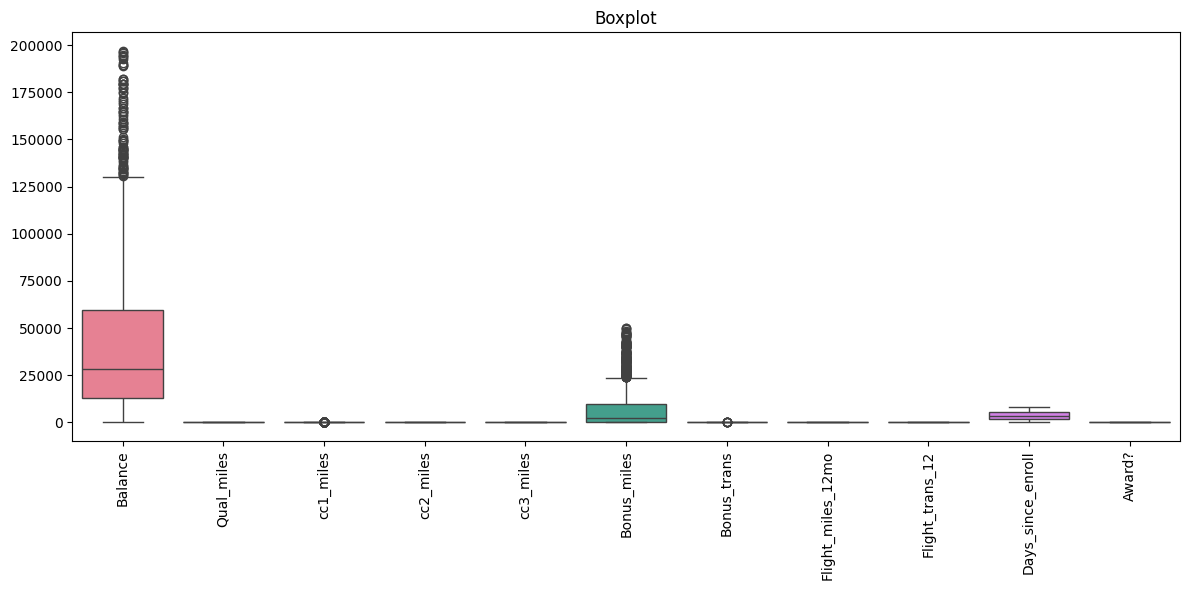

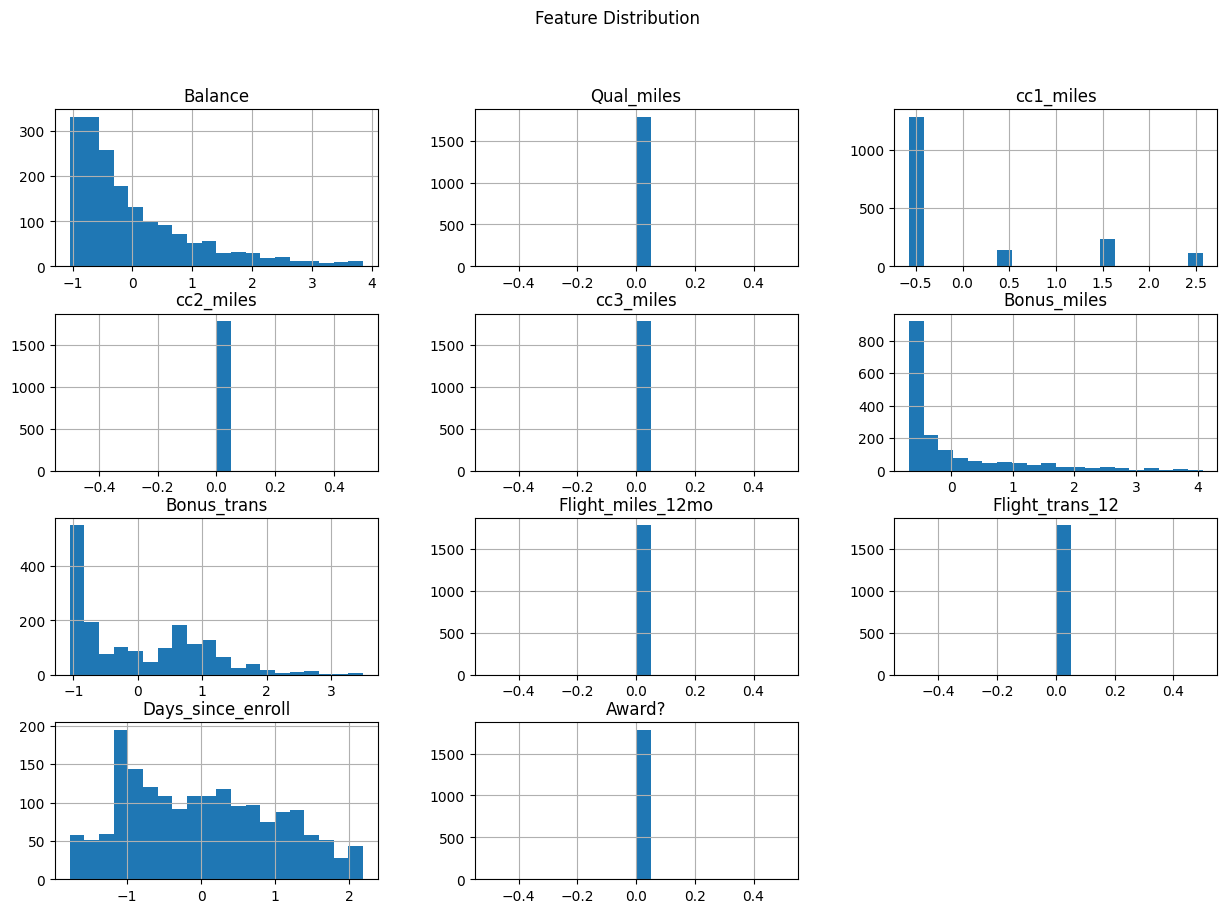

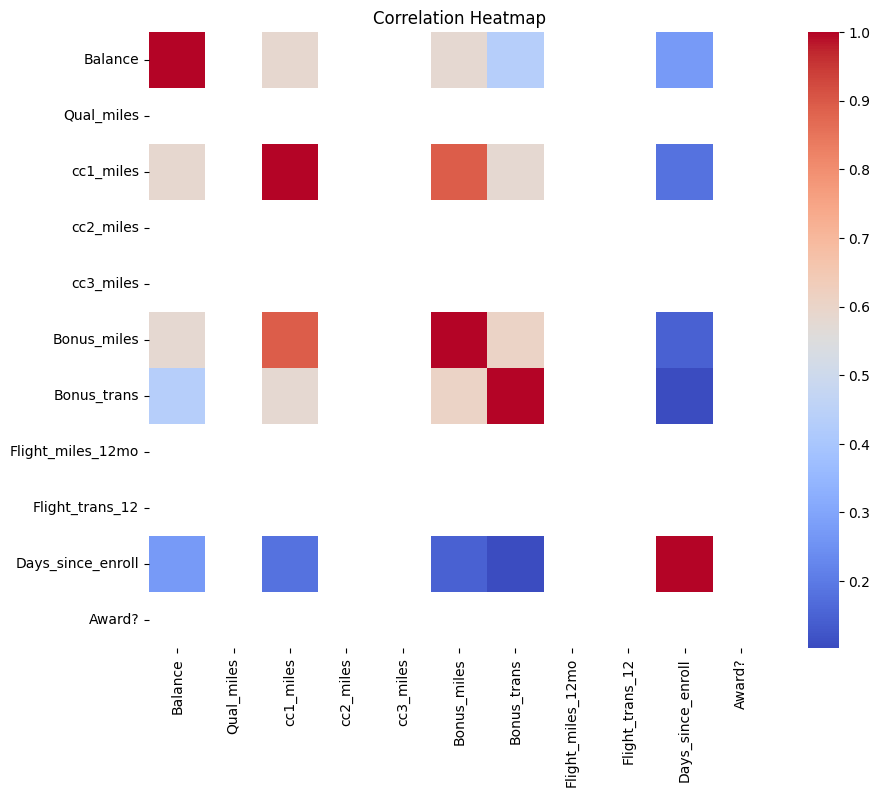

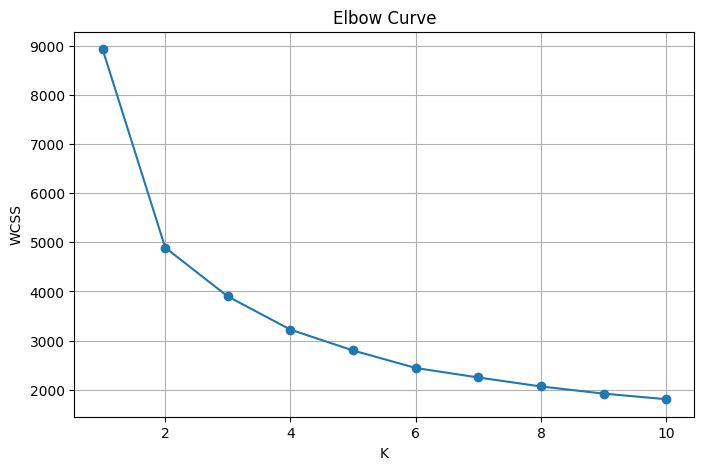


K-Means Silhouette Score: 0.3158


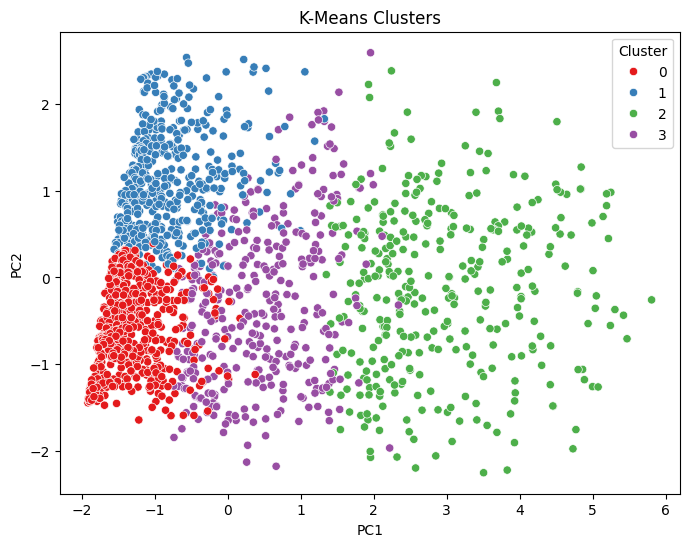


DBSCAN PARAMETER TUNING RESULTS
   eps  min_samples  clusters  silhouette_score
0  0.5            3        29           -0.1363
1  0.5            5        11           -0.0495
2  0.5            8         8           -0.1106
3  0.5           10         5           -0.0869
4  1.0            3         6            0.2395
5  1.0            5         5            0.2438
6  1.0            8         5            0.2369
7  1.0           10         4            0.2308

Best eps: 1.0
Best min_samples: 5

DBSCAN Silhouette Score: 0.2438


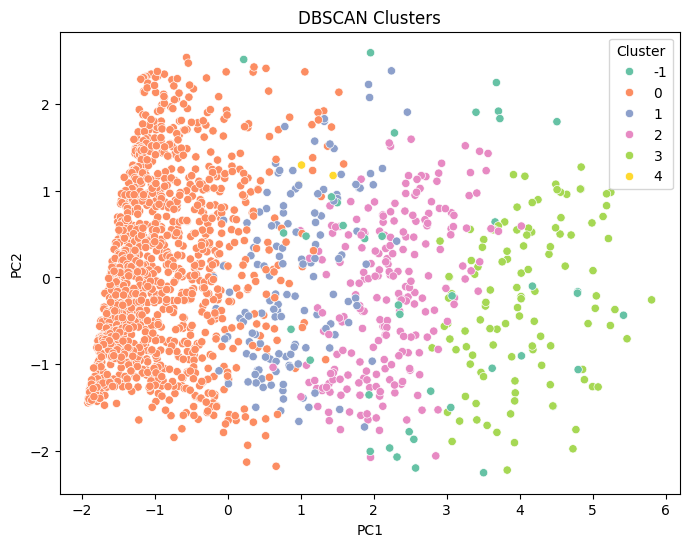


Cluster Summary
              Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  \
Cluster                                                              
0        19947.265866         0.0   1.008576        1.0        1.0   
1        28741.067210         0.0   1.030550        1.0        1.0   
2        90742.681159         0.0   3.284058        1.0        1.0   
3        50218.546448         0.0   1.453552        1.0        1.0   

          Bonus_miles  Bonus_trans  Flight_miles_12mo  Flight_trans_12  \
Cluster                                                                  
0         1452.518010     2.480274                0.0              0.0   
1         1626.130346     3.150713                0.0              0.0   
2        24984.620290    15.327536                0.0              0.0   
3         6733.896175    14.849727                0.0              0.0   

         Days_since_enroll  Award?  
Cluster                             
0              1853.708405     0.0  
1     

In [4]:
# ==========================================
# CLUSTERING ANALYSIS - EASTWEST AIRLINES
# ==========================================

import os
os.environ["OMP_NUM_THREADS"] = "7"

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ==========================================
# 1. LOAD DATASET
# ==========================================

try:
    df = pd.read_excel("EastWestAirlines.xlsx", sheet_name="data")
except:
    df = pd.read_excel("EastWestAirlines.xlsx")

print("Dataset Shape:", df.shape)

# ==========================================
# 2. DATA PREPROCESSING
# ==========================================

print("\nMissing Values:")
print(df.isnull().sum())

# Drop ID column if present
for col in ["ID#", "ID"]:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

# Keep only numeric columns
df = df.select_dtypes(include=np.number)

print("\nNumeric Columns Used:")
print(df.columns.tolist())

# Fill missing values if any
df = df.fillna(df.median())

# ==========================================
# 3. OUTLIER REMOVAL
# ==========================================

def remove_outliers(data):

    data_clean = data.copy()

    numeric_cols = data_clean.columns

    for col in numeric_cols:

        Q1 = data_clean[col].quantile(0.25)
        Q3 = data_clean[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        data_clean = data_clean[
            (data_clean[col] >= lower) &
            (data_clean[col] <= upper)
        ]

    return data_clean

df_clean = remove_outliers(df)

print("\nShape Before Outlier Removal :", df.shape)
print("Shape After Outlier Removal  :", df_clean.shape)

# ==========================================
# 4. FEATURE SCALING
# ==========================================

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_clean)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=df_clean.columns
)

# ==========================================
# 5. EDA
# ==========================================

plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean)
plt.xticks(rotation=90)
plt.title("Boxplot")
plt.tight_layout()
plt.show()

scaled_df.hist(figsize=(15,10), bins=20)
plt.suptitle("Feature Distribution")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df_clean.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ==========================================
# 6. ELBOW METHOD
# ==========================================

wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_df)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Curve")
plt.grid(True)
plt.show()

# ==========================================
# 7. K-MEANS
# ==========================================

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(scaled_df)

kmeans_score = silhouette_score(
    scaled_df,
    kmeans_labels
)

print("\nK-Means Silhouette Score:", round(kmeans_score,4))

# ==========================================
# 8. K-MEANS VISUALIZATION
# ==========================================

pca = PCA(n_components=2)

kmeans_pca = pca.fit_transform(scaled_df)

kmeans_plot = pd.DataFrame(
    kmeans_pca,
    columns=["PC1","PC2"]
)

kmeans_plot["Cluster"] = kmeans_labels

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=kmeans_plot,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1"
)

plt.title("K-Means Clusters")
plt.show()

# ==========================================
# 9. DBSCAN PARAMETER TUNING
# ==========================================

results = []

eps_values = [0.5, 1.0, 1.5, 2.0]
min_samples_values = [3,5,8,10]

for eps in eps_values:

    for min_pts in min_samples_values:

        db = DBSCAN(
            eps=eps,
            min_samples=min_pts
        )

        labels = db.fit_predict(scaled_df)

        n_clusters = len(set(labels)) - (
            1 if -1 in labels else 0
        )

        if n_clusters > 1:

            try:

                score = silhouette_score(
                    scaled_df,
                    labels
                )

                results.append([
                    eps,
                    min_pts,
                    n_clusters,
                    round(score,4)
                ])

            except:
                pass

results_df = pd.DataFrame(
    results,
    columns=[
        "eps",
        "min_samples",
        "clusters",
        "silhouette_score"
    ]
)

print("\nDBSCAN PARAMETER TUNING RESULTS")
print(results_df)

# ==========================================
# 10. BEST DBSCAN MODEL
# ==========================================

if len(results_df) > 0:

    best_row = results_df.sort_values(
        by="silhouette_score",
        ascending=False
    ).iloc[0]

    best_eps = best_row["eps"]
    best_min_samples = int(best_row["min_samples"])

    print("\nBest eps:", best_eps)
    print("Best min_samples:", best_min_samples)

    dbscan = DBSCAN(
        eps=best_eps,
        min_samples=best_min_samples
    )

    db_labels = dbscan.fit_predict(
        scaled_df
    )

    if len(set(db_labels)) > 1:

        db_score = silhouette_score(
            scaled_df,
            db_labels
        )

        print(
            "\nDBSCAN Silhouette Score:",
            round(db_score,4)
        )

    # ======================================
    # DBSCAN VISUALIZATION
    # ======================================

    db_pca = PCA(
        n_components=2
    ).fit_transform(
        scaled_df
    )

    db_plot = pd.DataFrame(
        db_pca,
        columns=["PC1","PC2"]
    )

    db_plot["Cluster"] = db_labels

    plt.figure(figsize=(8,6))

    sns.scatterplot(
        data=db_plot,
        x="PC1",
        y="PC2",
        hue="Cluster",
        palette="Set2"
    )

    plt.title("DBSCAN Clusters")
    plt.show()

else:

    print(
        "\nNo valid DBSCAN clusters found."
    )

# ==========================================
# 11. CLUSTER ANALYSIS
# ==========================================

cluster_df = df_clean.copy()

cluster_df["Cluster"] = kmeans_labels

cluster_summary = cluster_df.groupby(
    "Cluster"
).mean()

print("\nCluster Summary")
print(cluster_summary)

# ==========================================
# 12. INSIGHTS
# ==========================================

print("\n========== INSIGHTS ==========")

print("1. K-Means successfully segmented airline customers.")

print("2. Elbow Method was used to determine K.")

print("3. Multiple DBSCAN parameters were tested.")

print("4. Best DBSCAN parameters were selected using silhouette score.")

print("5. DBSCAN identified dense groups and possible outliers.")

print("6. Customer segments can be used for targeted marketing.")